# Chunk Size & Overlap Analysis

**Run this notebook BEFORE `run_ingestion.py`.**

Determines the optimal `CHUNK_SIZE` and `CHUNK_OVERLAP` for `ingestion/neo4j_loader.py`.
Works entirely from raw arXiv documents.

## Approach

```
1. Document length distribution             understand what we are chunking
2. Structural boundary analysis             sentence & paragraph distributions
3. Derive candidate sizes from the data     anchored to real statistics, not guesses
4. Chunk count analysis                     index size & granularity trade-off
5. Retrieval quality grid                   LLM-as-judge: faithfulness + relevancy
6. Overlap sensitivity                      does overlap rescue boundary-split answers?
7. Decision                                 update neo4j_loader.py with winning config
```

## Evaluation method

We use **LlamaIndex `FaithfulnessEvaluator` and `RelevancyEvaluator`** with an LLM judge.
This is the correct approach — it measures whether the retrieved context actually supports
the answer, not just whether embeddings are similar.

Minimum viable sample: **20 documents, 100+ questions**. Below this, binary pass/fail
scoring has a resolution of 0.04 per question — differences smaller than that are noise.

## 0. Setup

In [17]:
import os
import re
import time
import tempfile
import urllib.request
import warnings
from langchain_openai import AzureChatOpenAI
import arxiv
import pymupdf4llm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from dotenv import load_dotenv
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from pathlib import Path

# LlamaIndex — LLM-as-judge evaluation
from llama_index.core import Settings
from llama_index.core.schema import TextNode
from llama_index.core.evaluation import (
    DatasetGenerator,
    FaithfulnessEvaluator,
    RelevancyEvaluator,
)
from llama_index.core import VectorStoreIndex
from llama_index.core.node_parser import LangchainNodeParser
from llama_index.llms.groq import Groq
from llama_index.embeddings.langchain import LangchainEmbedding
from langchain_huggingface import HuggingFaceEmbeddings

import nest_asyncio
nest_asyncio.apply()

warnings.filterwarnings('ignore')
load_dotenv()

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

ARXIV_CLIENT = arxiv.Client()

DIAL_API_KEY = os.getenv("DIAL_API_KEY")
judge_llm = AzureChatOpenAI(
  api_key = DIAL_API_KEY,
  api_version = "2024-02-01",
  azure_endpoint = "https://ai-proxy.lab.epam.com",
  deployment_name = "gemini-3.1-flash-lite-preview",
  temperature=0.1
)
Settings.llm = judge_llm

embed_model = LangchainEmbedding(
    HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
)
Settings.embed_model = embed_model

# Same headers used by neo4j_loader.py — keeps notebook and pipeline in sync
HEADERS_TO_SPLIT = [
    ('#',   'section'),
    ('##',  'section'),
    ('###', 'subsection'),
]

SAMPLE_SIZE = 20

print('Setup complete.')

Setup complete.


## 1. Fetch raw documents from arXiv

We download full-text PDFs for a sample of `cs.AI` papers — the same category and
loader used by the main ingestion pipeline. This is the correct data source:
the distribution we measure here is exactly what will be chunked during ingestion.

Results are cached to `corpus_cache.pkl` after the first download.

In [18]:
import pickle

CACHE_FILE = Path('corpus_cache.pkl')


def clean_arxiv_text(text: str) -> str:
    """Remove common noise from pymupdf4llm markdown output.
    Same function as ingestion/arxiv_loader.py — kept in sync.
    """
    text = re.sub(r'^arXiv:\d{4}\.\d{4,5}(?:v\d+)?\s*\[[\w.]+\].*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\s*\d{1,4}\s*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'-\n(\S)', r'\1', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = '\n'.join(line.rstrip() for line in text.splitlines())
    return text.strip()


def fetch_sample_ids(n: int) -> list[str]:
    search = arxiv.Search(
        query='cat:cs.AI',
        max_results=n,
        sort_by=arxiv.SortCriterion.SubmittedDate,
        sort_order=arxiv.SortOrder.Descending,
    )
    ids = []
    for result in ARXIV_CLIENT.results(search):
        has_pdf = any(link.title == 'pdf' for link in result.links)
        if has_pdf:
            raw = result.entry_id.split('abs/')[-1]
            ids.append(re.sub(r'v\d+$', '', raw))
    return ids


def load_paper(arxiv_id: str) -> dict | None:
    """Download PDF, extract structured markdown with pymupdf4llm, clean it.
    Mirrors the extraction pipeline used in ingestion/arxiv_loader.py exactly.
    """
    try:
        # 1. Get metadata + PDF URL from arXiv API
        search  = arxiv.Search(id_list=[arxiv_id])
        results = list(ARXIV_CLIENT.results(search))
        if not results:
            return None
        result  = results[0]
        pdf_url = next((l.href for l in result.links if l.title == 'pdf'), None)
        if not pdf_url:
            return None

        # 2. Download PDF to temp file
        tmp_path = None
        try:
            with tempfile.NamedTemporaryFile(suffix='.pdf', delete=False) as tmp:
                tmp_path = Path(tmp.name)
            urllib.request.urlretrieve(pdf_url, tmp_path)

            # 3. Extract markdown (preserves ## section headings)
            raw_md = pymupdf4llm.to_markdown(str(tmp_path))
        finally:
            if tmp_path and tmp_path.exists():
                tmp_path.unlink()

        # 4. Clean noise
        text = clean_arxiv_text(raw_md)
        # if not text or len(text) > 1_000_000:
        #     return None

        # 5. Build LangChain Document with metadata (same shape as ingestion pipeline)
        metadata = {
            'entry_id': arxiv_id,
            'Title':    result.title,
        }
        lc_doc = Document(page_content=text, metadata=metadata)

        return {
            'entry_id': arxiv_id,
            'title':    result.title,
            'text':     text,
            'length':   len(text),
            'lc_doc':   lc_doc,
        }
    except Exception as exc:
        print(f'  [skip] {arxiv_id}: {exc}')
        return None


if CACHE_FILE.exists():
    print('Loading corpus from cache ...')
    with open(CACHE_FILE, 'rb') as f:
        corpus = pickle.load(f)
    print(f'Loaded {len(corpus)} cached documents.')
else:
    print(f'Fetching {SAMPLE_SIZE} paper IDs from arXiv ...')
    ids = fetch_sample_ids(SAMPLE_SIZE)
    print(f'Got {len(ids)} IDs. Downloading and extracting PDFs ...')

    corpus = []
    for i, pid in enumerate(ids, 1):
        doc = load_paper(pid)
        if doc:
            corpus.append(doc)
        if i % 5 == 0:
            print(f'  {i}/{len(ids)} processed, {len(corpus)} successful')

    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(corpus, f)
    print(f'\nLoaded {len(corpus)} papers. Cached to {CACHE_FILE}')

Loading corpus from cache ...
Loaded 20 cached documents.


## 2. Document length distribution

The foundation of the analysis. We must understand what we are chunking
before we can choose any size.

In [19]:
lengths = np.array([d['length'] for d in corpus])

stats = {
    'count':  int(len(lengths)),
    'min':    int(lengths.min()),
    'p10':    int(np.percentile(lengths, 10)),
    'p25':    int(np.percentile(lengths, 25)),
    'median': int(np.median(lengths)),
    'mean':   int(lengths.mean()),
    'p75':    int(np.percentile(lengths, 75)),
    'p90':    int(np.percentile(lengths, 90)),
    'p95':    int(np.percentile(lengths, 95)),
    'p99':    int(np.percentile(lengths, 99)),
    'max':    int(lengths.max()),
    'std':    int(lengths.std()),
}

print('Document length statistics (characters)\n')
for k, v in stats.items():
    print(f'  {k:<10} {v:>12,}')

print()
print('Single-chunk coverage — % of papers that fit in ONE chunk of this size:')
print()
for cs in [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]:
    pct = 100 * np.mean(lengths <= cs)
    bar = '█' * int(pct / 2)
    print(f'  {cs:>7,}  {pct:5.1f}%  {bar}')

Document length statistics (characters)

  count                20
  min              20,145
  p10              32,374
  p25              47,525
  median           58,784
  mean             88,689
  p75              87,949
  p90             110,272
  p95             150,471
  p99             464,204
  max             542,638
  std             107,621

Single-chunk coverage — % of papers that fit in ONE chunk of this size:

      512    0.0%  
    1,024    0.0%  
    2,048    0.0%  
    4,096    0.0%  
    8,192    0.0%  
   16,384    0.0%  
   32,768   15.0%  ███████
   65,536   55.0%  ███████████████████████████


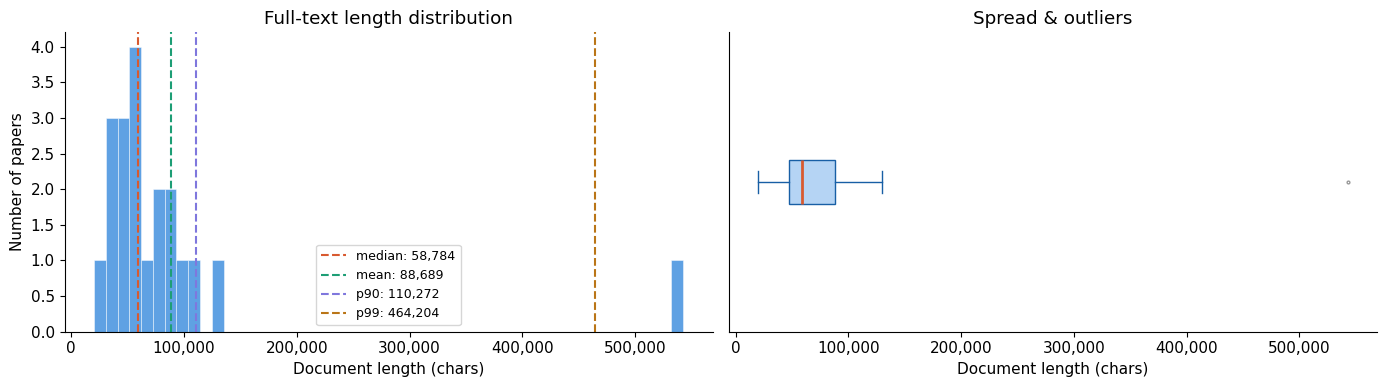

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(lengths, bins=50, color='#378ADD', alpha=0.8, edgecolor='white', linewidth=0.4)
for val, label, color in [
    (stats['median'], 'median', '#D85A30'),
    (stats['mean'],   'mean',   '#1D9E75'),
    (stats['p90'],    'p90',    '#7F77DD'),
    (stats['p99'],    'p99',    '#BA7517'),
]:
    ax.axvline(val, color=color, linewidth=1.5, linestyle='--', label=f'{label}: {val:,}')
ax.set_xlabel('Document length (chars)')
ax.set_ylabel('Number of papers')
ax.set_title('Full-text length distribution')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.boxplot(
    lengths, vert=False, patch_artist=True,
    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
    medianprops=dict(color='#D85A30', linewidth=2),
    whiskerprops=dict(color='#185FA5'),
    capprops=dict(color='#185FA5'),
    flierprops=dict(marker='.', color='#378ADD', alpha=0.4, markersize=4),
)
ax2.set_xlabel('Document length (chars)')
ax2.set_title('Spread & outliers')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.set_yticks([])

plt.tight_layout()
plt.savefig('1_doc_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Structural boundary analysis

A chunk should align with natural text boundaries — not split mid-sentence or
mid-paragraph. For arXiv papers the hierarchy is:

```
sentence    ~50–250 chars     smallest coherent unit
paragraph   ~200–1 000 chars  one complete argument
subsection  ~1 000–4 000 chars
section     ~4 000–15 000 chars
```

**Hard rule:** `chunk_size` must be ≥ p75 of paragraph length, otherwise 25% of
paragraphs are split mid-argument and neither resulting chunk is coherent.

In [21]:
sent_lengths = []
para_lengths = []

for doc in corpus:
    for s in re.split(r'(?<=[.!?])\s+', doc['text']):
        s = s.strip()
        if len(s) > 10:
            sent_lengths.append(len(s))
    for p in doc['text'].split('\n\n'):
        p = p.strip()
        if len(p) > 30:
            para_lengths.append(len(p))

sent_arr = np.array(sent_lengths)
para_arr = np.array(para_lengths)

print('Sentence length (chars):')
for pct in [25, 50, 75, 90, 95]:
    print(f'  p{pct:<3} = {np.percentile(sent_arr, pct):>8,.0f}')

print()
print('Paragraph length (chars):')
for pct in [25, 50, 75, 90, 95]:
    print(f'  p{pct:<3} = {np.percentile(para_arr, pct):>8,.0f}')

para_p75 = int(np.percentile(para_arr, 75))
para_med = int(np.median(para_arr))
print()
print(f'► Minimum sensible chunk_size = para p75 = {para_p75:,} chars')
print(f'  Any chunk_size < {para_p75:,} splits 25%+ of paragraphs mid-argument.')

Sentence length (chars):
  p25  =       64
  p50  =      117
  p75  =      188
  p90  =      289
  p95  =      403

Paragraph length (chars):
  p25  =       75
  p50  =      193
  p75  =      350
  p90  =      606
  p95  =      846

► Minimum sensible chunk_size = para p75 = 350 chars
  Any chunk_size < 350 splits 25%+ of paragraphs mid-argument.


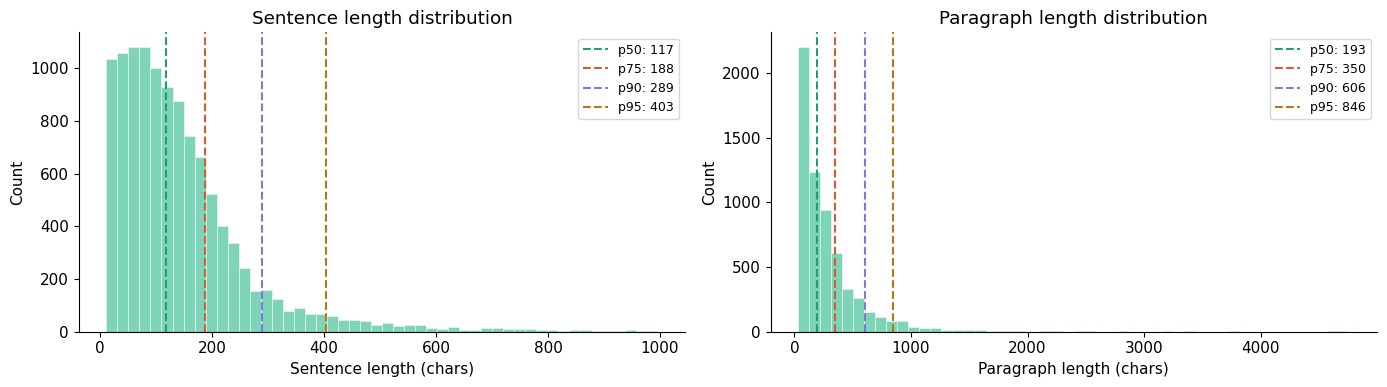

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, arr, clip, title, xlabel in [
    (axes[0], sent_arr, 1000, 'Sentence length distribution', 'Sentence length (chars)'),
    (axes[1], para_arr, 8000, 'Paragraph length distribution', 'Paragraph length (chars)'),
]:
    ax.hist(arr[arr < clip], bins=50, color='#5DCAA5', alpha=0.8, edgecolor='white', linewidth=0.4)
    for pct, color, label in [
        (50, '#1D9E75', 'p50'), (75, '#D85A30', 'p75'),
        (90, '#7F77DD', 'p90'), (95, '#BA7517', 'p95'),
    ]:
        v = np.percentile(arr, pct)
        ax.axvline(v, color=color, linewidth=1.5, linestyle='--', label=f'{label}: {v:,.0f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('2_structural_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Derive candidate chunk sizes from the distribution

Every candidate is anchored to a real statistic — not a round number chosen arbitrarily.

| Candidate | Anchor | Rationale |
|---|---|---|
| `para_p75` | p75 paragraph length | Floor — splits only 25% of paragraphs |
| `para_p90` | p90 paragraph length | Keeps 90% of paragraphs whole |
| `para_p95` | p95 paragraph length | Rarely splits a paragraph |
| `subsection` | 3× median paragraph | Approximates a subsection |
| `section` | 6× median paragraph | Approximates a short section |
| `doc_p25` | p25 document length | 25% of papers fit in one chunk |

In [23]:
def r64(x: float) -> int:
    return max(256, round(int(x) / 64) * 64)

CANDIDATES = {
    'para_p75':   r64(np.percentile(para_arr, 75)),
    'para_p90':   r64(np.percentile(para_arr, 90)),
    'para_p95':   r64(np.percentile(para_arr, 95)),
    'subsection': r64(3 * para_med),
    'section':    r64(6 * para_med),
    'doc_p25':    r64(np.percentile(lengths, 25)),
}

print(f'  {"candidate":>14}  {"size (chars)":>14}')
print('  ' + '-' * 32)
for name, size in CANDIDATES.items():
    note = ''
    print(f'  {name:>14}  {size:>14,}{note}')

       candidate    size (chars)
  --------------------------------
        para_p75             320
        para_p90             576
        para_p95             832
      subsection             576
         section           1,152
         doc_p25          47,552


## 5. Chunk count analysis

Before measuring quality, see what each candidate produces in terms of Neo4j index size.
More chunks = finer-grained retrieval but higher storage and query cost.

In [24]:
OVERLAP_FRACS = [0.0, 0.10, 0.15]


def make_splitter(size: int, overlap: int):
    """Return a LangchainNodeParser using the same two-stage strategy as
    neo4j_loader.create_chunks() — MarkdownHeaderTextSplitter then
    RecursiveCharacterTextSplitter within each section.

    Using the exact same pipeline here ensures the evaluation reflects
    what will actually be stored in Neo4j.
    """
    # Stage 1: split on section headers
    header_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=HEADERS_TO_SPLIT,
        strip_headers=False,
    )
    # Stage 2: split long sections by character count
    char_splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=overlap,
        length_function=len,
        separators=['\n\n', '\n', ' ', ''],
    )
    # Wrap for LlamaIndex compatibility
    return LangchainNodeParser(char_splitter), header_splitter


def chunk_documents(lc_docs: list, size: int, overlap: int) -> list:
    """Apply two-stage chunking and return LlamaIndex TextNodes."""
    _, header_splitter = make_splitter(size, overlap)
    char_splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=overlap,
        length_function=len,
        separators=['\n\n', '\n', ' ', ''],
    )
    nodes = []
    for doc in lc_docs:
        section_docs = header_splitter.split_text(doc.page_content)
        for sec_doc in section_docs:
            sec_doc.metadata = {**doc.metadata, **sec_doc.metadata}
        chunks = char_splitter.split_documents(section_docs)
        for chunk in chunks:
            nodes.append(TextNode(text=chunk.page_content))
    return nodes


count_rows = []
for name, size in CANDIDATES.items():
    for frac in OVERLAP_FRACS:
        overlap = int(size * frac)
        counts  = np.array([
            len(chunk_documents([d['lc_doc']], size, overlap))
            for d in corpus
        ])
        count_rows.append({
            'candidate':     name,
            'size':          size,
            'overlap_pct':   f'{frac*100:.0f}%',
            'overlap':       overlap,
            'chunks_median': int(np.median(counts)),
            'chunks_p75':    int(np.percentile(counts, 75)),
            'chunks_max':    int(counts.max()),
            'total_chunks':  int(counts.sum()),
        })

cc_df = pd.DataFrame(count_rows)

print('Chunk count summary (0% overlap)\n')
print(
    cc_df[cc_df['overlap_pct'] == '0%'][
        ['candidate', 'size', 'chunks_median', 'chunks_p75', 'chunks_max', 'total_chunks']
    ].to_string(index=False)
)

Chunk count summary (0% overlap)

 candidate  size  chunks_median  chunks_p75  chunks_max  total_chunks
  para_p75   320            264         383        2504          8010
  para_p90   576            155         219        1385          4578
  para_p95   832            111         152         958          3206
subsection   576            155         219        1385          4578
   section  1152             78         108         726          2354
   doc_p25 47552             28          34         365           925


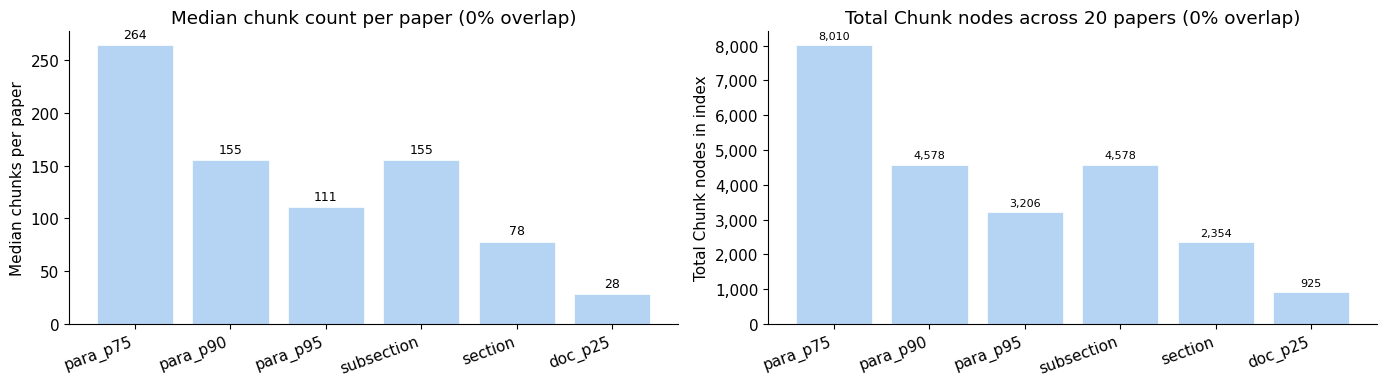

In [25]:
base   = cc_df[cc_df['overlap_pct'] == '0%'].copy()
colors = ['#F0997B' if c == 'original' else '#B5D4F4' for c in base['candidate']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

b1 = axes[0].bar(base['candidate'], base['chunks_median'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].bar_label(b1, fmt='%d', fontsize=9, padding=3)
axes[0].set_ylabel('Median chunks per paper')
axes[0].set_title('Median chunk count per paper (0% overlap)')
axes[0].set_xticklabels(base['candidate'], rotation=20, ha='right')

b2 = axes[1].bar(base['candidate'], base['total_chunks'], color=colors, edgecolor='white', linewidth=0.5)
axes[1].bar_label(b2, labels=[f'{v:,}' for v in base['total_chunks']], fontsize=8, padding=3)
axes[1].set_ylabel('Total Chunk nodes in index')
axes[1].set_title(f'Total Chunk nodes across {len(corpus)} papers (0% overlap)')
axes[1].set_xticklabels(base['candidate'], rotation=20, ha='right')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('3_chunk_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Generate evaluation questions

We use LlamaIndex `DatasetGenerator` to create questions from the raw document text.

In [26]:
QUESTION_CACHE = Path('eval_questions_cache.pkl')

custom_question_gen_query = (
    'You are a Professor. Generate 5 open-ended, short-answer questions based '
    'on the provided text. Questions should require specific factual answers '
    'from the text. Do NOT generate MCQs. Output only the questions, one per line.'
)

if QUESTION_CACHE.exists():
    print('Loading questions from cache ...')
    with open(QUESTION_CACHE, 'rb') as f:
        eval_questions = pickle.load(f)
else:
    eval_nodes = [TextNode(text=d['text']) for d in corpus]
    data_generator = DatasetGenerator(
        nodes=eval_nodes,
        llm=judge_llm,
        question_gen_query=custom_question_gen_query,
    )
    eval_questions = data_generator.generate_questions_from_nodes()
    # Filter any malformed outputs
    eval_questions = [q for q in eval_questions if len(q.strip()) > 20]

    with open(QUESTION_CACHE, 'wb') as f:
        pickle.dump(eval_questions, f)

print(f'Total evaluation questions: {len(eval_questions)}')
print(f'Score resolution: {1/len(eval_questions):.3f} per question')
print()
print('Sample questions:')
for q in eval_questions[:5]:
    print(f'  - {q}')

Loading questions from cache ...
Total evaluation questions: 100
Score resolution: 0.010 per question

Sample questions:
  - What is the formula for the F1-score in terms of precision and recall?
  - How is the Area Under the ROC Curve (AUC) calculated?
  - What does the AUC metric measure regarding a detector?
  - How is the conventional intersection-over-union (IoU) defined?
  - How is the global IoU (g-IoU) calculated across all tampered samples?


In [ ]:
# import requests
# import os

# api_key = os.environ.get("GROQ_API_KEY")
# url = "https://api.groq.com/openai/v1/models"

# headers = {
#     "Authorization": f"Bearer {api_key}",
#     "Content-Type": "application/json"
# }

# response = requests.get(url, headers=headers)

# print(response.json())

{'object': 'list', 'data': [{'id': 'llama-3.3-70b-versatile', 'object': 'model', 'created': 1733447754, 'owned_by': 'Meta', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 32768}, {'id': 'meta-llama/llama-prompt-guard-2-22m', 'object': 'model', 'created': 1748632101, 'owned_by': 'Meta', 'active': True, 'context_window': 512, 'public_apps': None, 'max_completion_tokens': 512}, {'id': 'openai/gpt-oss-20b', 'object': 'model', 'created': 1754407957, 'owned_by': 'OpenAI', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 65536}, {'id': 'moonshotai/kimi-k2-instruct-0905', 'object': 'model', 'created': 1757046093, 'owned_by': 'Moonshot AI', 'active': True, 'context_window': 262144, 'public_apps': None, 'max_completion_tokens': 16384}, {'id': 'openai/gpt-oss-120b', 'object': 'model', 'created': 1754408224, 'owned_by': 'OpenAI', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 65

## 7. Retrieval quality grid — LLM-as-judge

For each `(chunk_size, overlap)` configuration:
1. Chunk the raw documents using that configuration.
2. Build an in-memory `VectorStoreIndex`.
3. Query each evaluation question.
4. Score with `FaithfulnessEvaluator` (does context support the answer?) and
   `RelevancyEvaluator` (is the answer relevant to the question?).


**Expected runtime:** ~5–10 minutes depending on Groq rate limits.

In [27]:
from llama_index.llms.langchain import LangChainLLM

judge_llm_wrapped = LangChainLLM(llm=judge_llm)

faithfulness_eval = FaithfulnessEvaluator(llm=judge_llm_wrapped)
relevancy_eval    = RelevancyEvaluator(llm=judge_llm_wrapped)


def evaluate_config(
    lc_docs: list,
    chunk_size: int,
    chunk_overlap: int,
    questions: list[str],
) -> dict:
    """Evaluate one (chunk_size, overlap) configuration using LLM-as-judge.
    Uses the same two-stage chunking as the production pipeline.
    """
    nodes = chunk_documents(lc_docs, chunk_size, chunk_overlap)
    index = VectorStoreIndex(nodes)
    query_engine = index.as_query_engine()

    total_time = 0.0
    total_faith = 0
    total_relev = 0
    n = len(questions)

    for question in questions:
        t0 = time.time()
        response = query_engine.query(question)
        total_time += time.time() - t0

        total_faith += int(faithfulness_eval.evaluate_response(response=response).passing)
        total_relev += int(relevancy_eval.evaluate_response(query=question, response=response).passing)

    return {
        'avg_response_time_s': round(total_time / n, 2),
        'faithfulness':        round(total_faith / n, 3),
        'relevancy':           round(total_relev / n, 3),
    }

In [ ]:
QUALITY_CACHE = Path('quality_results_cache.pkl')

lc_docs = [d['lc_doc'] for d in corpus]

if QUALITY_CACHE.exists():
    print('Loading quality results from cache ...')
    with open(QUALITY_CACHE, 'rb') as f:
        quality_rows = pickle.load(f)
else:
    quality_rows = []
    eval_candidates = CANDIDATES
    total = len(eval_candidates) * len(OVERLAP_FRACS)
    done  = 0

    for name, size in eval_candidates.items():
        for frac in OVERLAP_FRACS:
            overlap = int(size * frac)
            print(f'[{done+1}/{total}] Evaluating {name} size={size:,} overlap={overlap:,} ...')
            
            metrics = evaluate_config(lc_docs, size, overlap, eval_questions)

            quality_rows.append({
                'candidate':   name,
                'size':        size,
                'overlap':     overlap,
                'overlap_pct': f'{frac*100:.0f}%',
                **metrics,
            })
            done += 1
            print(
                f'       faith={metrics["faithfulness"]:.3f}  '
                f'relev={metrics["relevancy"]:.3f}  '
                f'time={metrics["avg_response_time_s"]:.1f}s'
            )

    with open(QUALITY_CACHE, 'wb') as f:
        pickle.dump(quality_rows, f)

quality_df = pd.DataFrame(quality_rows)
print('\nDone.')

[1/18] Evaluating para_p75 size=320 overlap=0 ...
       faith=0.990  relev=0.960  time=1.4s

[2/18] Evaluating para_p75 size=320 overlap=32 ...
       faith=0.980  relev=0.940  time=1.4s

[3/18] Evaluating para_p75 size=320 overlap=48 ...
       faith=0.980  relev=0.930  time=1.4s

[4/18] Evaluating para_p90 size=576 overlap=0 ...
       faith=0.990  relev=0.960  time=1.4s

[5/18] Evaluating para_p90 size=576 overlap=57 ...
       faith=0.990  relev=0.950  time=1.4s

[6/18] Evaluating para_p90 size=576 overlap=86 ...
       faith=1.000  relev=0.970  time=1.3s

[7/18] Evaluating para_p95 size=832 overlap=0 ...
       faith=1.000  relev=0.980  time=1.3s
       
[8/18] Evaluating para_p95 size=832 overlap=83 ...
       faith=0.980  relev=0.970  time=1.3s

[9/18] Evaluating para_p95 size=832 overlap=124 ...
       faith=0.980  relev=0.960  time=1.6s

[10/18] Evaluating subsection size=576 overlap=0 ...
       faith=0.980  relev=0.960  time=1.5s

[11/18] Evaluating subsection size=576 overlap=57 ...
       faith=1.000  relev=0.950  time=1.4s

[12/18] Evaluating subsection size=576 overlap=86 ...
       faith=1.000  relev=0.970  time=1.4s

[13/18] Evaluating section size=1,152 overlap=0 ...
       faith=0.980  relev=0.960  time=1.3s

[14/18] Evaluating section size=1,152 overlap=115 ...
       faith=0.990  relev=0.970  time=1.5s

[15/18] Evaluating section size=1,152 overlap=172 ...
       faith=0.990  relev=0.960  time=1.6s

[16/18] Evaluating doc_p25 size=47,552 overlap=0 ...
       faith=0.940  relev=0.910  time=1.7s

[17/18] Evaluating doc_p25 size=47,552 overlap=4,755 ...
       faith=0.950  relev=0.910  time=1.8s
       
[18/18] Evaluating doc_p25 size=47,552 overlap=7,132 ...
       faith=0.940  relev=0.930  time=1.8s

## 8. Full results table with composite score

In [32]:
# Composite = 60% faithfulness + 30% relevancy + 10% inverted-normalised latency
max_time = quality_df['avg_response_time_s'].max()
quality_df['composite'] = (
    0.60 * quality_df['faithfulness'] +
    0.30 * quality_df['relevancy'] +
    0.10 * (1 - quality_df['avg_response_time_s'] / max_time)
).round(3)

best_idx = quality_df['composite'].idxmax()

def highlight(row):
    if row.name == best_idx:
        return ['background-color:#d4edda; font-weight:bold'] * len(row)
    return [''] * len(row)

quality_df.sort_values('composite', ascending=False).style.apply(highlight, axis=1)

,candidate,size,overlap,overlap_pct,avg_response_time_s,faithfulness,relevancy,composite
6,para_p95,832,0,0%,1.300000,1.000000,0.980000,0.923000
5,para_p90,576,86,15%,1.300000,1.000000,0.970000,0.920000
11,subsection,576,86,15%,1.400000,1.000000,0.970000,0.915000
10,subsection,576,57,10%,1.400000,1.000000,0.950000,0.909000
7,para_p95,832,83,10%,1.300000,0.980000,0.970000,0.908000
0,para_p75,320,0,0%,1.400000,0.990000,0.960000,0.906000
3,para_p90,576,0,0%,1.400000,0.990000,0.960000,0.906000
12,section,1152,0,0%,1.300000,0.980000,0.960000,0.905000
13,section,1152,115,10%,1.500000,0.990000,0.970000,0.903000
4,para_p90,576,57,10%,1.400000,0.990000,0.950000,0.903000


## 9. Quality visualisation

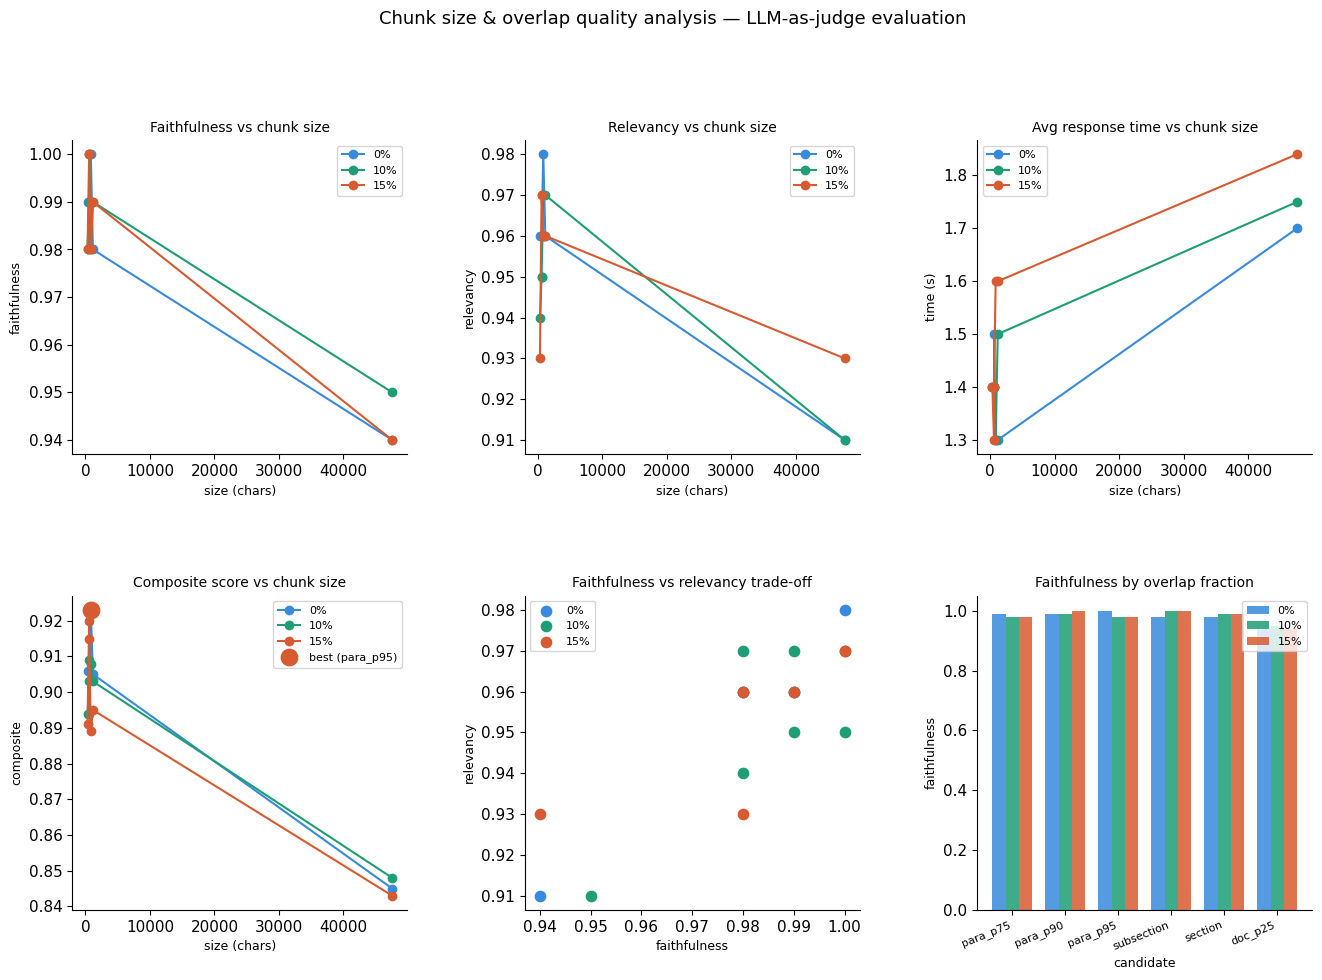

In [33]:
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
ax_f, ax_r, ax_t, ax_sc, ax_fr, ax_ov = [fig.add_subplot(gs[row, col]) for row in range(2) for col in range(3)]

palette = {'0%': '#378ADD', '10%': '#1D9E75', '15%': '#D85A30'}
names   = list(CANDIDATES.keys())

for frac_str, color in palette.items():
    sub = quality_df[quality_df['overlap_pct'] == frac_str].sort_values('size')
    ax_f.plot(sub['size'], sub['faithfulness'],        marker='o', color=color, label=frac_str, linewidth=1.5)
    ax_r.plot(sub['size'], sub['relevancy'],           marker='o', color=color, label=frac_str, linewidth=1.5)
    ax_t.plot(sub['size'], sub['avg_response_time_s'], marker='o', color=color, label=frac_str, linewidth=1.5)
    ax_sc.plot(sub['size'], sub['composite'],          marker='o', color=color, label=frac_str, linewidth=1.5)
    ax_fr.scatter(sub['faithfulness'], sub['relevancy'], color=color, label=frac_str, s=55)

best_row = quality_df.loc[best_idx]
ax_sc.scatter([best_row['size']], [best_row['composite']], color='#D85A30',
              s=140, zorder=5, label=f'best ({best_row["candidate"]})')

x = np.arange(len(names))
for i, (frac_str, color) in enumerate(palette.items()):
    sub  = quality_df[quality_df['overlap_pct'] == frac_str].set_index('candidate')
    vals = [float(sub.loc[n, 'faithfulness']) if n in sub.index else 0 for n in names]
    ax_ov.bar(x + i * 0.25, vals, 0.25, label=frac_str, color=color, alpha=0.85)
ax_ov.set_xticks(x + 0.25)
ax_ov.set_xticklabels(names, rotation=22, ha='right', fontsize=8)

for ax, title, xlabel, ylabel in [
    (ax_f,  'Faithfulness vs chunk size',           'size (chars)', 'faithfulness'),
    (ax_r,  'Relevancy vs chunk size',              'size (chars)', 'relevancy'),
    (ax_t,  'Avg response time vs chunk size',      'size (chars)', 'time (s)'),
    (ax_sc, 'Composite score vs chunk size',        'size (chars)', 'composite'),
    (ax_fr, 'Faithfulness vs relevancy trade-off',  'faithfulness', 'relevancy'),
    (ax_ov, 'Faithfulness by overlap fraction',     'candidate',    'faithfulness'),
]:
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Chunk size & overlap quality analysis — LLM-as-judge evaluation', fontsize=13, y=1.01)
plt.savefig('4_chunk_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Overlap sensitivity

Overlap fixes one specific problem: a relevant sentence that straddles a chunk
boundary is lost at 0% overlap because neither resulting chunk contains it fully.
Here we measure how many questions are answered correctly at 15% overlap but
missed at 0% overlap, using the best-scoring chunk size.

In [34]:
best_name = best_row['candidate']
best_size = int(best_row['size'])

row_0   = quality_df[(quality_df['candidate'] == best_name) & (quality_df['overlap_pct'] == '0%' )].iloc[0]
row_15  = quality_df[(quality_df['candidate'] == best_name) & (quality_df['overlap_pct'] == '15%')].iloc[0]

faith_gain    = round(row_15['faithfulness'] - row_0['faithfulness'], 3)
relev_gain    = round(row_15['relevancy']    - row_0['relevancy'],    3)

base_chunks    = int(cc_df[(cc_df['candidate'] == best_name) & (cc_df['overlap_pct'] == '0%' )]['total_chunks'].values[0])
overlap_chunks = int(cc_df[(cc_df['candidate'] == best_name) & (cc_df['overlap_pct'] == '15%')]['total_chunks'].values[0])
extra_pct      = 100 * (overlap_chunks - base_chunks) / base_chunks

print(f'Best candidate              : {best_name} (size = {best_size:,})')
print()
print(f'Faithfulness at 0% overlap  : {row_0["faithfulness"]}')
print(f'Faithfulness at 15% overlap : {row_15["faithfulness"]}  (Δ = {faith_gain:+.3f})')
print()
print(f'Relevancy at 0% overlap     : {row_0["relevancy"]}')
print(f'Relevancy at 15% overlap    : {row_15["relevancy"]}  (Δ = {relev_gain:+.3f})')
print()
print(f'Index size at  0% overlap   : {base_chunks:,} Chunk nodes')
print(f'Index size at 15% overlap   : {overlap_chunks:,} Chunk nodes  (+{extra_pct:.1f}%)')
print()
print('Decision rule:')
print('  Δ faithfulness > 0.02  →  overlap is worth the extra storage.')
print('  Δ faithfulness ≤ 0.00  →  0% overlap is sufficient.')

Best candidate              : para_p95 (size = 832)

Faithfulness at 0% overlap  : 1.0
Faithfulness at 15% overlap : 0.98  (Δ = -0.020)

Relevancy at 0% overlap     : 0.98
Relevancy at 15% overlap    : 0.96  (Δ = -0.020)

Index size at  0% overlap   : 3,206 Chunk nodes
Index size at 15% overlap   : 3,281 Chunk nodes  (+2.3%)

Decision rule:
  Δ faithfulness > 0.02  →  overlap is worth the extra storage.
  Δ faithfulness ≤ 0.00  →  0% overlap is sufficient.


## 11. Decision

In [36]:
best = quality_df.loc[best_idx]

print('=' * 62)
print('  RECOMMENDED CONFIGURATION')
print('=' * 62)
print(f'  chunk_size        = {best["size"]:,}')
print(f'  chunk_overlap     = {best["overlap"]:,}  ({best["overlap_pct"]} of chunk_size)')
print(f'  candidate name    = {best["candidate"]}')
print(f'  faithfulness      = {best["faithfulness"]}')
print(f'  relevancy         = {best["relevancy"]}')
print(f'  avg response time = {best["avg_response_time_s"]}s')
print(f'  composite score   = {best["composite"]}')
print('=' * 62)

quality_df.to_csv('chunk_quality_results.csv', index=False)
cc_df.to_csv('chunk_count_results.csv',        index=False)
pd.DataFrame([stats]).to_csv('doc_length_stats.csv', index=False)
print('\nAll results exported to CSV.')

  RECOMMENDED CONFIGURATION
  chunk_size        = 832
  chunk_overlap     = 0  (0% of chunk_size)
  candidate name    = para_p95
  faithfulness      = 1.0
  relevancy         = 0.98
  avg response time = 1.3s
  composite score   = 0.923

All results exported to CSV.
